# CNN v3 Live Inference — 24-Hour Carbon Intensity Forecast

This model uses only **24 hours** of history (not 14 days), making it even simpler to deploy.

## What's different from the previous CNN
| | CNN v1 (336h) | CNN v3 (24h) |
|---|---|---|
| Input window | 336 hours (14 days) | **24 hours (1 day)** |
| Features | 7 (target, diffs, time) | **5 (target, time only)** |
| Scaling | Target only | **Target + features separately** |
| Data needed | 14 days of history | **1 day of history** |

## Required Files
- `final_model.keras` (or convert to TFLite below)
- `scaler_params_cnn_v3.json`


In [1]:
import os
import json
import requests
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.21.0


In [2]:
# ─── Config (from model_params.json and scaler_params_cnn_v3.json) ───
WINDOW_SIZE = 24           # only 24 hours of history needed!
FORECAST_HORIZON = 24
TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

FEATURES = [TARGET_COL, "hour_sin", "hour_cos", "year_sin", "year_cos"]
FEATURE_COLS = ["hour_sin", "hour_cos", "year_sin", "year_cos"]  # non-target features

# ─── Model file ───
KERAS_PATH = "final_model.keras"
TFLITE_PATH = "carbon_model_cnn_v3.tflite"
SCALER_PATH = "scaler_params_cnn_v3.json"

print(f"Keras model: {KERAS_PATH} (exists: {os.path.exists(KERAS_PATH)})")
print(f"Scaler: {SCALER_PATH} (exists: {os.path.exists(SCALER_PATH)})")
print(f"Window: {WINDOW_SIZE}h → Forecast: {FORECAST_HORIZON}h")
print(f"Features: {FEATURES}")


Keras model: final_model.keras (exists: False)
Scaler: scaler_params_cnn_v3.json (exists: True)
Window: 24h → Forecast: 24h
Features: ['Carbon intensity gCO₂eq/kWh (direct)', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos']


# Load / Convert Model

In [3]:
# Load scaler
with open(SCALER_PATH) as f:
    scaler = json.load(f)

target_mean = scaler["target_mean"][0]
target_scale = scaler["target_scale"][0]
feature_mean = np.array(scaler["feature_mean"])    # 4 values (hour_sin, hour_cos, year_sin, year_cos)
feature_scale = np.array(scaler["feature_scale"])  # 4 values

print(f"Target scaler — mean: {target_mean:.2f}, scale: {target_scale:.2f}")
print(f"Feature means: {feature_mean}")
print(f"Feature scales: {feature_scale}")


Target scaler — mean: 119.11, scale: 63.88
Feature means: [-1.67631848e-17 -5.67109356e-17 -5.19117980e-17  0.00000000e+00]
Feature scales: [0.70710678 0.70710678 0.70710678 0.70710678]


In [4]:
# Convert Keras to TFLite if needed
if not os.path.exists(TFLITE_PATH):
    print(f"Converting {KERAS_PATH} to TFLite...")
    keras_model = tf.keras.models.load_model(KERAS_PATH)
    keras_model.summary()
    
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_model = converter.convert()
    
    with open(TFLITE_PATH, "wb") as f:
        f.write(tflite_model)
    print(f"✓ Saved: {TFLITE_PATH} ({os.path.getsize(TFLITE_PATH)/1024:.1f} KB)")
else:
    print(f"✓ TFLite already exists: {TFLITE_PATH}")

# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(f"\nModel: {input_details[0]['shape']} → {output_details[0]['shape']}")


✓ TFLite already exists: carbon_model_cnn_v3.tflite

Model: [ 1 24  5] → [ 1 24]


/Users/artemziablov/Desktop/SDU-2-semester/Research_in_Software_Engineering/MAJJ-ADL-eris/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


# Fetch Live Carbon Intensity

Only need the last ~2 days from Energi Data Service (24h window + small buffer).


In [5]:
def fetch_carbon_intensity(days_back=3):
    """Fetch recent carbon intensity from Energi Data Service."""
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        "start": f"now-P{days_back}D",
        "filter": json.dumps({"PriceArea": ["DK1", "DK2"]}),
        "sort": "Minutes5UTC asc",
        "limit": 0,
    }
    
    print(f"Fetching CO2Emis (last {days_back} days)...")
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    records = resp.json().get("records", [])
    if not records:
        raise ValueError("No data returned from API")
    
    df = pd.DataFrame(records)
    df["Datetime (UTC)"] = pd.to_datetime(df["Minutes5UTC"])
    
    # Average DK1+DK2, resample to hourly
    hourly = (df.groupby(pd.Grouper(key="Datetime (UTC)", freq="1h"))["CO2Emission"]
              .mean().reset_index())
    hourly.columns = ["Datetime (UTC)", TARGET_COL]
    hourly = hourly.dropna().sort_values("Datetime (UTC)").reset_index(drop=True)
    
    print(f"✓ {len(records)} records → {len(hourly)} hourly rows")
    print(f"  {hourly['Datetime (UTC)'].iloc[0]} to {hourly['Datetime (UTC)'].iloc[-1]}")
    print(f"  Range: {hourly[TARGET_COL].min():.1f} - {hourly[TARGET_COL].max():.1f} gCO₂eq/kWh")
    return hourly

carbon_df = fetch_carbon_intensity()


Fetching CO2Emis (last 3 days)...
✓ 1728 records → 73 hourly rows
  2026-04-11 15:00:00 to 2026-04-14 15:00:00
  Range: 26.4 - 119.0 gCO₂eq/kWh


# Build Input Tensor

CNN v3 scaling:
- **Target** (carbon intensity): scaled with target_mean/target_scale
- **Features** (hour_sin, hour_cos, year_sin, year_cos): scaled with feature_mean/feature_scale
- **No diffs** — this model doesn't use diff_1 or diff_24


In [6]:
def build_cnn_v3_input(carbon_df):
    df = carbon_df.copy()
    
    # Compute time features
    dt = df["Datetime (UTC)"]
    df["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)
    df["year_sin"] = np.sin(2 * np.pi * dt.dt.dayofyear / 365)
    df["year_cos"] = np.cos(2 * np.pi * dt.dt.dayofyear / 365)
    
    if len(df) < WINDOW_SIZE:
        raise ValueError(f"Need {WINDOW_SIZE} rows, have {len(df)}")
    
    # Scale target separately
    df[TARGET_COL] = (df[TARGET_COL] - target_mean) / target_scale
    
    # Scale features separately
    df[FEATURE_COLS] = (df[FEATURE_COLS].values - feature_mean) / feature_scale
    
    # Take most recent 24 hours
    recent = df.tail(WINDOW_SIZE).copy()
    last_ts = recent["Datetime (UTC)"].iloc[-1]
    
    tensor = recent[FEATURES].values.astype(np.float32).reshape(1, WINDOW_SIZE, len(FEATURES))
    
    print(f"Input: {recent['Datetime (UTC)'].iloc[0]} to {last_ts}")
    print(f"  Shape: {tensor.shape}")
    return tensor, last_ts

input_tensor, last_timestamp = build_cnn_v3_input(carbon_df)


Input: 2026-04-13 16:00:00 to 2026-04-14 15:00:00
  Shape: (1, 24, 5)


# Run Prediction

In [7]:
interpreter.set_tensor(input_details[0]['index'], input_tensor)
interpreter.invoke()
pred_scaled = interpreter.get_tensor(output_details[0]['index'])[0]

# Inverse scale
pred_values = pred_scaled * target_scale + target_mean
forecast_times = [last_timestamp + timedelta(hours=h+1) for h in range(FORECAST_HORIZON)]

forecast_df = pd.DataFrame({
    "Datetime (UTC)": forecast_times,
    "Hour": range(1, 25),
    "gCO₂eq/kWh": pred_values.round(1),
})

print(f"\n24-Hour Forecast (CNN v3) — from {last_timestamp}")
print(forecast_df.to_string(index=False))



24-Hour Forecast (CNN v3) — from 2026-04-14 15:00:00
     Datetime (UTC)  Hour  gCO₂eq/kWh
2026-04-14 16:00:00     1   85.800003
2026-04-14 17:00:00     2   85.500000
2026-04-14 18:00:00     3   86.400002
2026-04-14 19:00:00     4   87.500000
2026-04-14 20:00:00     5   87.199997
2026-04-14 21:00:00     6   87.599998
2026-04-14 22:00:00     7   88.500000
2026-04-14 23:00:00     8   89.300003
2026-04-15 00:00:00     9   91.000000
2026-04-15 01:00:00    10   91.400002
2026-04-15 02:00:00    11   91.699997
2026-04-15 03:00:00    12   91.699997
2026-04-15 04:00:00    13   90.900002
2026-04-15 05:00:00    14   92.199997
2026-04-15 06:00:00    15   91.699997
2026-04-15 07:00:00    16   91.699997
2026-04-15 08:00:00    17   91.599998
2026-04-15 09:00:00    18   91.300003
2026-04-15 10:00:00    19   91.000000
2026-04-15 11:00:00    20   90.599998
2026-04-15 12:00:00    21   91.000000
2026-04-15 13:00:00    22   92.400002
2026-04-15 14:00:00    23   92.099998
2026-04-15 15:00:00    24   92.000

# Visualize

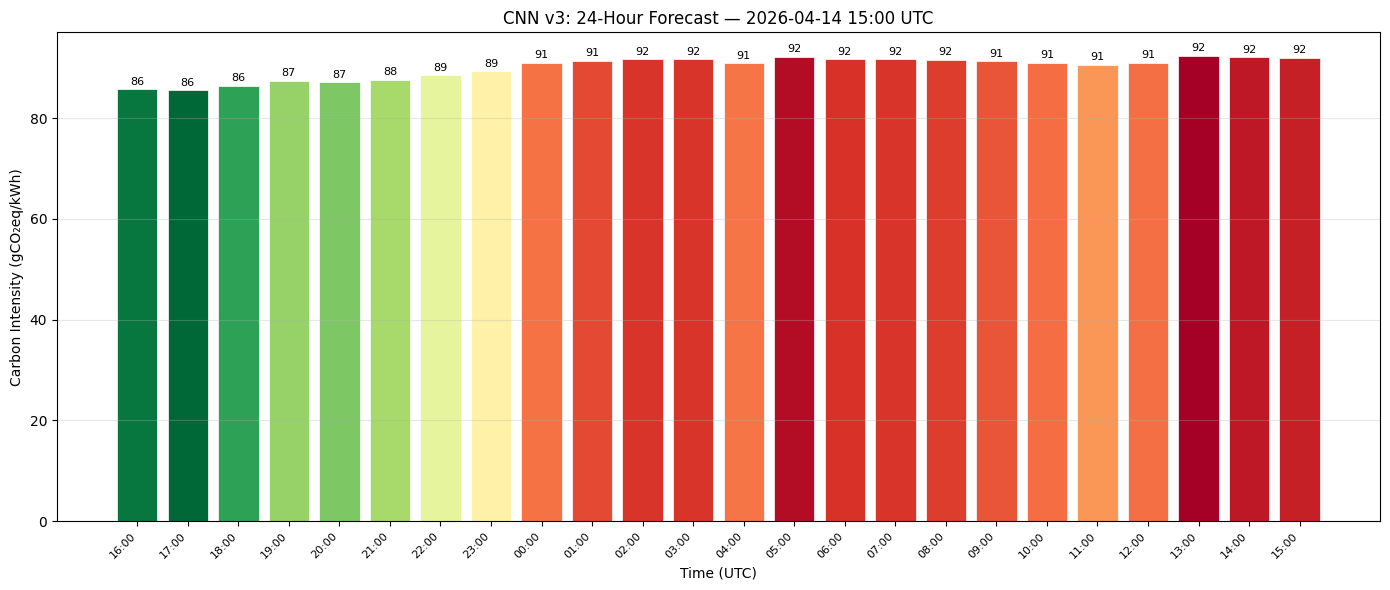

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn_r((pred_values - pred_values.min()) / (pred_values.max() - pred_values.min() + 1e-6))
ax.bar(range(1, 25), pred_values, color=colors, edgecolor="white", linewidth=0.5)
for h, v in enumerate(pred_values, 1):
    ax.text(h, v + 0.5, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
labels = [t.strftime("%H:%M") for t in forecast_times]
ax.set_xticks(range(1, 25))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
ax.set_title(f"CNN v3: 24-Hour Forecast — {last_timestamp.strftime('%Y-%m-%d %H:%M UTC')}")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


# Optimal Charging Window

🔋 Best 3-Hour Charging Window
  16:00 — 19:00 UTC
  Avg: 85.9 gCO₂eq/kWh
  Worst window: 92.1 gCO₂eq/kWh
  Savings: 6.2 gCO₂eq/kWh (7%)


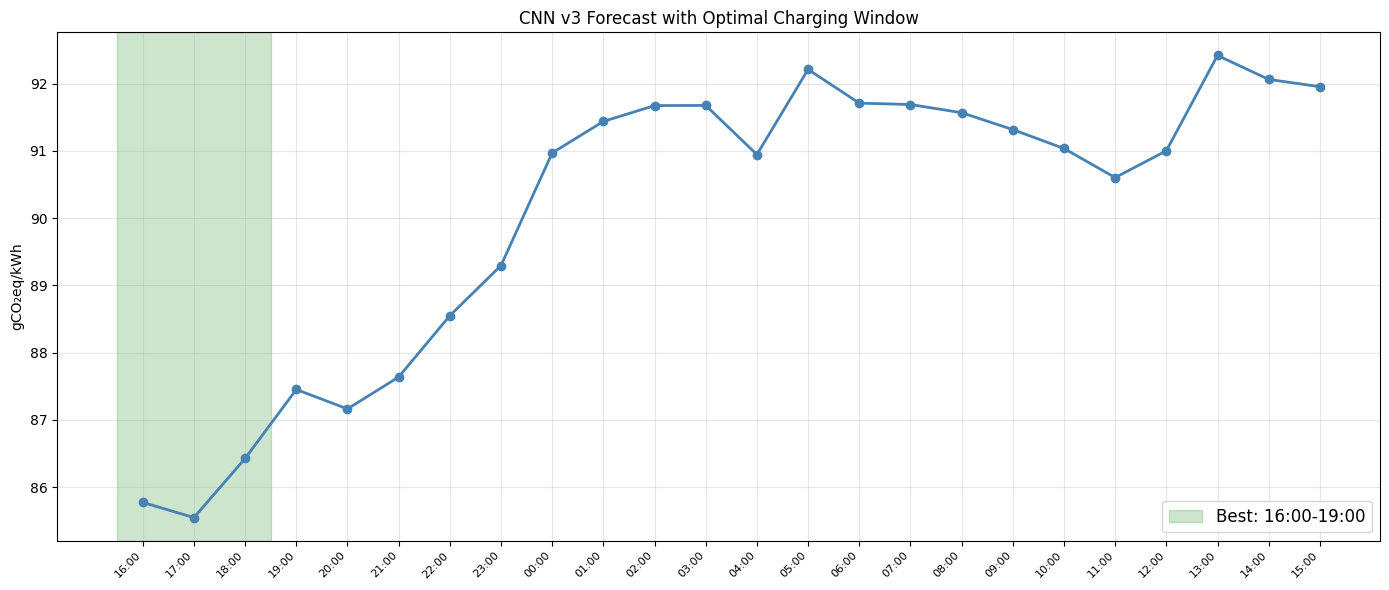

In [9]:
best_avg, best_start = float("inf"), 0
for i in range(len(pred_values) - 2):
    avg = pred_values[i:i+3].mean()
    if avg < best_avg:
        best_avg, best_start = avg, i

worst_avg = max(pred_values[i:i+3].mean() for i in range(len(pred_values)-2))

print(f"🔋 Best 3-Hour Charging Window")
print(f"  {forecast_times[best_start].strftime('%H:%M')} — "
      f"{(forecast_times[best_start] + timedelta(hours=3)).strftime('%H:%M')} UTC")
print(f"  Avg: {best_avg:.1f} gCO₂eq/kWh")
print(f"  Worst window: {worst_avg:.1f} gCO₂eq/kWh")
print(f"  Savings: {worst_avg - best_avg:.1f} gCO₂eq/kWh ({(worst_avg-best_avg)/worst_avg*100:.0f}%)")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(1,25), pred_values, "o-", linewidth=2, color="steelblue")
ax.axvspan(best_start+0.5, best_start+3.5, alpha=0.2, color="green",
           label=f"Best: {forecast_times[best_start].strftime('%H:%M')}-"
                 f"{(forecast_times[best_start]+timedelta(hours=3)).strftime('%H:%M')}")
ax.set_xticks(range(1,25))
ax.set_xticklabels([t.strftime("%H:%M") for t in forecast_times], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("gCO₂eq/kWh")
ax.set_title("CNN v3 Forecast with Optimal Charging Window")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Save Forecast

In [10]:
output = {
    "model": "CNN_v3",
    "window_hours": WINDOW_SIZE,
    "generated_at": last_timestamp.isoformat(),
    "best_window": {
        "start": forecast_times[best_start].isoformat(),
        "end": (forecast_times[best_start] + timedelta(hours=3)).isoformat(),
        "avg_co2": round(float(best_avg), 1),
    },
    "forecast": [
        {"time": t.isoformat(), "co2": round(float(v), 1)}
        for t, v in zip(forecast_times, pred_values)
    ],
}
with open("cnn_v3_forecast.json", "w") as f:
    json.dump(output, f, indent=2, default=str)
print("Saved: cnn_v3_forecast.json")


Saved: cnn_v3_forecast.json


# Mobile App Integration

## Even Simpler Than CNN v1

CNN v3 only needs **24 hours** of data (not 14 days), making the app pipeline trivial:

```
App opens → Fetch last 24h from API → Compute 4 time features → Run TFLite → Show result
```

### Kotlin Implementation

```kotlin
// 1. Fetch just 24 hours (one lightweight API call)
val url = "https://api.energidataservice.dk/dataset/CO2Emis" +
    "?start=now-P2D&filter={\"PriceArea\":[\"DK1\",\"DK2\"]}" +
    "&sort=Minutes5UTC%20asc&limit=0"

// 2. Build input (24 hours × 5 features)
val input = FloatArray(24 * 5)
for (i in 0 until 24) {
    val ci = hourlyValues[i]
    val hour = timestamps[i].hour
    val doy = timestamps[i].dayOfYear
    
    // Feature 0: scaled target
    input[i*5 + 0] = ((ci - TARGET_MEAN) / TARGET_SCALE).toFloat()
    
    // Features 1-4: scaled time encodings
    input[i*5 + 1] = ((sin(2*PI*hour/24) - FEAT_MEAN[0]) / FEAT_SCALE[0]).toFloat()
    input[i*5 + 2] = ((cos(2*PI*hour/24) - FEAT_MEAN[1]) / FEAT_SCALE[1]).toFloat()
    input[i*5 + 3] = ((sin(2*PI*doy/365) - FEAT_MEAN[2]) / FEAT_SCALE[2]).toFloat()
    input[i*5 + 4] = ((cos(2*PI*doy/365) - FEAT_MEAN[3]) / FEAT_SCALE[3]).toFloat()
}

// 3. Run inference
val output = Array(1) { FloatArray(24) }
interpreter.run(arrayOf(input.reshape(1, 24, 5)), output)
val predictions = output[0].map { it * TARGET_SCALE + TARGET_MEAN }

// 4. Find best 3h window
var bestStart = 0; var bestAvg = Float.MAX_VALUE
for (i in 0..21) {
    val avg = (predictions[i] + predictions[i+1] + predictions[i+2]) / 3
    if (avg < bestAvg) { bestAvg = avg; bestStart = i }
}
```

### Advantages over CNN v1 (336h)
- **24 rows cached** instead of 336 — almost nothing
- **2-day API call** instead of 16 days — faster response
- **No diffs to compute** — just time encodings from the clock
- **Even simpler failure handling** — if API fails, 24h of cache is still fresh
